# Trabajo Práctico 2 (TP2) - Parte 2: Regresión Logística, Curva de Aprendizaje y Evaluación de Desempeño

### Machine Learning 1 (23433)
#### Facultad de Ingeniería - Universidad Nacional de Asunción (FIUNA)

---

## Objetivos de la Parte 2
1. Configurar una partición estratificada Train/Test (80% Train, 20% Test sobre 64,295 muestras) previniendo el fuga de datos (*data leakage*).
2. Diseñar un `ColumnTransformer` profesional con `SimpleImputer`, `PolynomialFeatures(degree=2)`, `StandardScaler` y `OneHotEncoder`.
3. Entrenar un modelo de `LogisticRegression(class_weight='balanced')` con optimización de hiperparámetros vía `GridSearchCV`.
4. Calcular y graficar la **Curva de Aprendizaje (`learning_curve`)** evaluando la convergencia en validación cruzada.
5. Optimizar el umbral de decisión ($	au^*$) e inspeccionar la Matriz de Confusión, Curva ROC (AUC) y Curva Precision-Recall.


In [1]:
# 1. Carga de Librerías y Dataset del TP2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Carga del Dataset del TP2
csv_path = 'reglamento_nuevo_unificado.csv'
df_raw = pd.read_csv(csv_path)
print(f"Dataset del TP2 cargado exitosamente: {df_raw.shape[0]:,} filas.")


Dataset del TP2 cargado exitosamente: 64,295 filas.


## Ejercicio 1: Partición Estratificada Train / Test

Define las listas de atributos numéricos `num_features` y categóricos `cat_features`.
Realiza una partición estratificada del 80% para entrenamiento (`X_train`) y 20% para prueba (`X_test`).


In [4]:
# =====================================================================
# INGENIERÍA DE VARIABLES EXIGIDA POR LAS COLUMNAS DE LA CÁTEDRA
# =====================================================================

career_code_mapping = {
    # === ESCRIBE TU CÓDIGO AQUÍ ===
    'CIV-PLS13': 'Ing. Civil', 'CIV-PLS23': 'Ing. Civil', 'INT9CONSTR': 'Ing. Civil',
    'INT9TRANSP': 'Ing. Civil', 'INT9ORTERR': 'Ing. Civil', 'INT9SANEHI': 'Ing. Civil',
    
    'ELE-PLS13': 'Ing. Electromecánica', 'ELE-PLS23': 'Ing. Electromecánica',
    'INT9ELECTR': 'Ing. Electromecánica', 'INT9SDIGYT': 'Ing. Electromecánica',
    
    'MCT-PLS13': 'Ing. Mecatrónica', 'MCT-PLS23': 'Ing. Mecatrónica', 'MCT9-OPT': 'Ing. Mecatrónica',
    
    'IND-PLS13': 'Ing. Industrial', 'IND-PLS23': 'Ing. Industrial',
    'INT9G-ECO': 'Ing. Industrial', 'INT9-PROYT': 'Ing. Industrial',
    
    'CGF-PLS13': 'Ing. Geográfica', 'CGF-PLS23': 'Ing. Geográfica', 'INT9RNYMA': 'Ing. Geográfica',
    
    'MEC-PLS13': 'Ing. Mecánica', 'MEC-PLS23': 'Ing. Mecánica',
    'INT9MECANI': 'Ing. Mecánica', 'MEC9-OPT': 'Ing. Mecánica',
    
    'ECA-PLS13': 'Ing. Electrónica', 'ECA-PLS23': 'Ing. Electrónica', 'ECA9-OPT': 'Ing. Electrónica'
}


df_clean = df_raw.copy()

# Mapear carreras y limpiar strings
df_clean['Carrera_Nombre'] = df_clean['Cod.Car.Sec'].astype(str).str.strip().map(career_code_mapping)
df_clean = df_clean.dropna(subset=['Aprobado', 'Carrera_Nombre']).copy()
df_clean['Target'] = (df_clean['Aprobado'] == 'S').astype(int)

# Crear las columnas limpias forzando a numérico (reemplazando NaNs por cero)
df_clean['Primer_Par_Clean'] = pd.to_numeric(df_clean['Primer.Par'], errors='coerce').fillna(0)
df_clean['Segundo_Par_Clean'] = pd.to_numeric(df_clean['Segundo.Par'], errors='coerce').fillna(0)
df_clean['TPLab_Clean'] = pd.to_numeric(df_clean['TPLab.'], errors='coerce').fillna(0)
df_clean['Firma_Clean'] = pd.to_numeric(df_clean['Firma'], errors='coerce').fillna(0)
df_clean['FirmaCalc_Clean'] = pd.to_numeric(df_clean['FirmaCalculada'], errors='coerce').fillna(0)
df_clean['Asis_Clean'] = pd.to_numeric(df_clean['Asis'], errors='coerce').fillna(0)

# Variables de ingeniería añadidas en la plantilla
df_clean['Score_Parciales'] = df_clean['Primer_Par_Clean'] + df_clean['Segundo_Par_Clean']
df_clean['Diff_Parciales'] = df_clean['Primer_Par_Clean'] - df_clean['Segundo_Par_Clean']

# Asegurar que Semestre sea tratado como variable de texto/categoría
df_clean['Semestre'] = df_clean['Semestre'].astype(str)

# =====================================================================
# EJERCICIO 1: IMPLEMENTACIÓN DE LA PARTICIÓN ESTRATIFICADA
# =====================================================================
# Atributos numéricos y categóricos indicados en la plantilla
num_features = ['Primer_Par_Clean', 'Segundo_Par_Clean', 'Score_Parciales', 'Diff_Parciales', 'TPLab_Clean', 'Firma_Clean', 'FirmaCalc_Clean', 'Asis_Clean']
cat_features = ['Carrera_Nombre', 'Semestre']

# Construir matrices X e y
X = df_clean[num_features + cat_features]
y = df_clean['Target']

# Particionar de forma estratificada con 80% Train y 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)
print("=== PARTICIÓN DE LA CÁTEDRA COMPLETADA ===")
# Extraemos el primer elemento de la tupla .shape usando [0] para aplicar el formato de millares con la coma
print(f"Dimensiones de X_train (80%): {X_train.shape[0]:,} filas, {X_train.shape[1]} columnas")
print(f"Dimensiones de X_test (20%):  {X_test.shape[0]:,} filas, {X_test.shape[1]} columnas")
print(f"Proporción de alumnos aprobados en entrenamiento: {y_train.mean()*100:.2f}%")



=== PARTICIÓN DE LA CÁTEDRA COMPLETADA ===
Dimensiones de X_train (80%): 51,436 filas, 10 columnas
Dimensiones de X_test (20%):  12,859 filas, 10 columnas
Proporción de alumnos aprobados en entrenamiento: 60.67%


## Ejercicio 2: Construcción del Preprocesador Profesional (`ColumnTransformer`)

Construye un `Pipeline` numérico con:
1. `SimpleImputer(strategy='median')`
2. `PolynomialFeatures(degree=2, include_bias=False)`
3. `StandardScaler()`

Y un `Pipeline` categórico con `SimpleImputer` y `OneHotEncoder(handle_unknown='ignore')`.


In [5]:
# TODO: Ensamblar num_transformer, cat_transformer y preprocessor
# === ESCRIBE TU CÓDIGO AQUÍ ===
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Prueba de control: Ajustamos y transformamos una muestra para verificar dimensiones
X_train_transformed = preprocessor.fit_transform(X_train)
print("=== VERIFICACIÓN DEL PREPROCESADOR ===")
print(f"Dimensiones de los datos de entrenamiento antes de transformar: {X_train.shape}")
print(f"Dimensiones de los datos de entrenamiento después de transformar: {X_train_transformed.shape}")


=== VERIFICACIÓN DEL PREPROCESADOR ===
Dimensiones de los datos de entrenamiento antes de transformar: (51436, 10)
Dimensiones de los datos de entrenamiento después de transformar: (51436, 53)


## Ejercicio 3: Entrenamiento del Modelo y Búsqueda en Malla (`GridSearchCV`)

Ensambla `full_pipeline` con `LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=2000)`.
Configura `GridSearchCV` sobre el parámetro de regularización `C` en `[0.01, 0.1, 1.0, 10.0]` con `scoring='f1'`.


In [6]:
# TODO: Instanciar full_pipeline y GridSearchCV
# === ESCRIBE TU CÓDIGO AQUÍ ===
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42, class_weight='balanced'))
])

param_grid = {'classifier__C': [0.01, 0.1, 1.0, 10.0]}

# Ajustamos n_jobs=-1 para paralelizar el cómputo en todos los núcleos de tu procesador y acelerar el ajuste
grid_search = GridSearchCV(
    estimator=full_pipeline, 
    param_grid=param_grid, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
    scoring='f1', 
    n_jobs=-1
)

print("Iniciando la búsqueda en malla (GridSearchCV) con validación cruzada...")
grid_search.fit(X_train, y_train)

# Extraemos y reportamos las métricas ganadoras
best_c = grid_search.best_params_['classifier__C']
best_f1 = grid_search.best_score_
best_model = grid_search.best_estimator_

print("\n=== OPTIMIZACIÓN DE HIPERPARÁMETROS COMPLETADA ===")
print(f"Mejor valor para la regularización C: {best_c}")
print(f"Mejor puntuación F1-Score promediada: {best_f1:.4f}")


Iniciando la búsqueda en malla (GridSearchCV) con validación cruzada...

=== OPTIMIZACIÓN DE HIPERPARÁMETROS COMPLETADA ===
Mejor valor para la regularización C: 0.1
Mejor puntuación F1-Score promediada: 0.8836


## Ejercicio 4: Graficación de la Curva de Aprendizaje (`learning_curve`)

Calcula y grafica la curva de aprendizaje utilizando `learning_curve` sobre `X_train` y `y_train` con 10 tamaños de entrenamiento (`np.linspace(0.1, 1.0, 10)`).


Calculando la Curva de Aprendizaje (esto puede tomar unos segundos)...


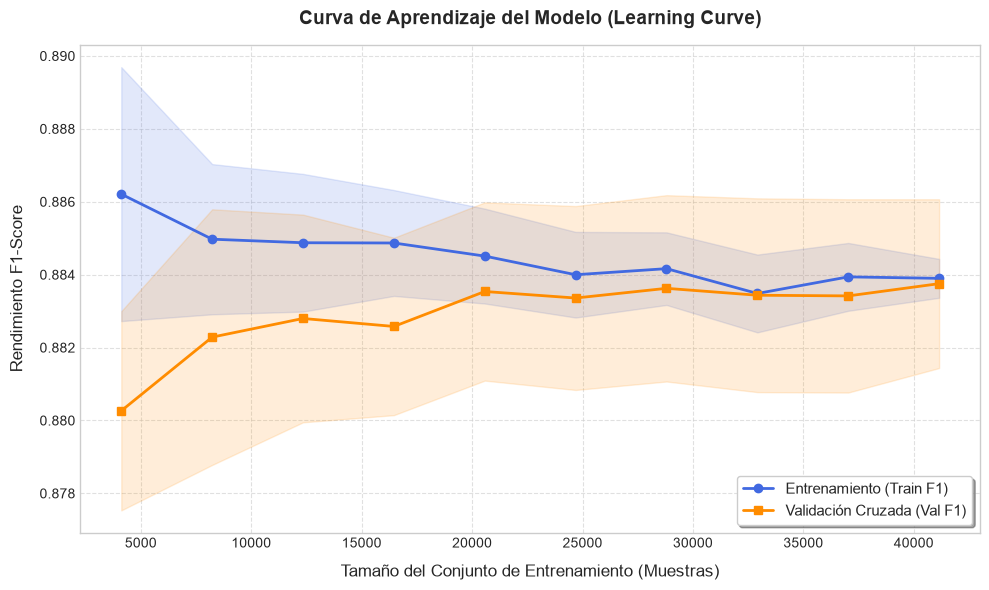

=== CURVA DE APRENDIZAJE GENERADA EXITOSAMENTE ===
F1-Score final en entrenamiento: 0.8839
F1-Score final en validación:    0.8838


In [8]:
# TODO: Calcular y graficar la Curva de Aprendizaje (Learning Curve)
# === ESCRIBE TU CÓDIGO AQUÍ ===

# Define los tamaños de entrenamiento solicitados (10 puntos del 10% al 100%)
train_sizes_pct = np.linspace(0.1, 1.0, 10)

print("Calculando la Curva de Aprendizaje (esto puede tomar unos segundos)...")
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model, 
    X=X_train, 
    y=y_train, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1', 
    train_sizes=train_sizes_pct, 
    n_jobs=-1
)

# Calculamos los promedios y desviaciones estándar de los scores obtenidos
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Generación del gráfico formal requerido por la cátedra
plt.figure(figsize=(10, 6))

# Curva de Entrenamiento
plt.plot(train_sizes, train_mean, "o-", color="royalblue", label="Entrenamiento (Train F1)", linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="royalblue")

# Curva de Validación
plt.plot(train_sizes, val_mean, "s-", color="darkorange", label="Validación Cruzada (Val F1)", linewidth=2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="darkorange")

# Detalles estéticos de la gráfica
plt.title("Curva de Aprendizaje del Modelo (Learning Curve)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tamaño del Conjunto de Entrenamiento (Muestras)", fontsize=12, labelpad=10)
plt.ylabel("Rendimiento F1-Score", fontsize=12, labelpad=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.tight_layout()

# Mostrar el gráfico en el notebook
plt.show()

print("=== CURVA DE APRENDIZAJE GENERADA EXITOSAMENTE ===")
print(f"F1-Score final en entrenamiento: {train_mean[-1]:.4f}")
print(f"F1-Score final en validación:    {val_mean[-1]:.4f}")





## Ejercicio 5: Optimización del Umbral de Decisión y Evaluación de Desempeño

En el conjunto de prueba (`X_test`):
1. Obtén las probabilidades de aprobación `y_proba_test`.
2. Optimiza el umbral de decisión ($	au^*$) entre `0.1` y `0.9` que maximiza el F1-Score.
3. Grafica la **Matriz de Confusión**, la **Curva ROC (AUC)** y la **Curva Precision-Recall**.


=== EVALUACIÓN CON UMBRAL OPTIMIZADO ===
Umbral Óptimo Seleccionado (tau*): 0.40
F1-Score obtenido en Test:        0.8889
Accuracy obtenido en Test:        0.8601


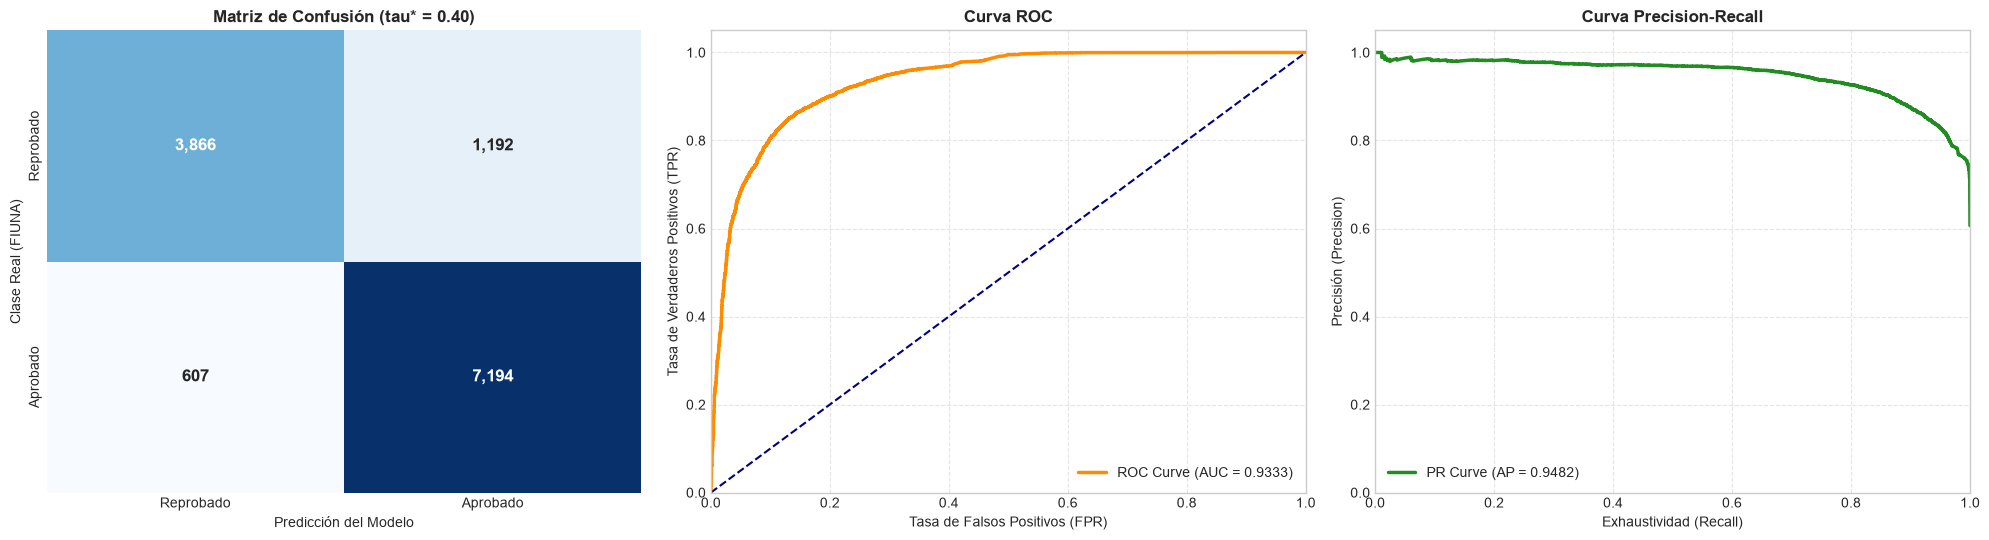

In [9]:
# TODO: Optimizar umbral y graficar métricas en Test
# === ESCRIBE TU CÓDIGO AQUÍ ===

# 1. Obtener las probabilidades de la clase positiva (Aprobado = 1) en Test
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# 2. Optimización programática del umbral buscando maximizar el F1-Score
umbrales = np.linspace(0.1, 0.9, 81)
mejores_metricas = {"umbral": 0.5, "f1": 0.0}

for t in umbrales:
    y_pred_temp = (y_proba_test >= t).astype(int)
    f1_temp = f1_score(y_test, y_pred_temp, zero_division=0)
    if f1_temp > mejores_metricas["f1"]:
        mejores_metricas["f1"] = f1_temp
        mejores_metricas["umbral"] = t

best_thresh = mejores_metricas["umbral"]
y_pred = (y_proba_test >= best_thresh).astype(int)

print("=== EVALUACIÓN CON UMBRAL OPTIMIZADO ===")
print(f"Umbral Óptimo Seleccionado (tau*): {best_thresh:.2f}")
print(f"F1-Score obtenido en Test:        {mejores_metricas['f1']:.4f}")
print(f"Accuracy obtenido en Test:        {accuracy_score(y_test, y_pred):.4f}")

# 3. Graficación de las 3 métricas de desempeño requeridas
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# --- GRÁFICO 1: Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Reprobado", "Aprobado"], yticklabels=["Reprobado", "Aprobado"],
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title(f"Matriz de Confusión (tau* = {best_thresh:.2f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicción del Modelo", fontsize=10)
axes[0].set_ylabel("Clase Real (FIUNA)", fontsize=10)

# --- GRÁFICO 2: Curva ROC (AUC) ---
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc_score = roc_auc_score(y_test, y_proba_test)
axes[1].plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC Curve (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title("Curva ROC", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=10)
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=10)
axes[1].legend(loc="lower right", shadow=True)
axes[1].grid(True, linestyle="--", alpha=0.5)

# --- GRÁFICO 3: Curva Precision-Recall (AP) ---
precision, recall, _ = precision_recall_curve(y_test, y_proba_test)
ap_score = average_precision_score(y_test, y_proba_test)
axes[2].plot(recall, precision, color="forestgreen", lw=2.5, label=f"PR Curve (AP = {ap_score:.4f})")
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_title("Curva Precision-Recall", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Exhaustividad (Recall)", fontsize=10)
axes[2].set_ylabel("Precisión (Precision)", fontsize=10)
axes[2].legend(loc="lower left", shadow=True)
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
